## Introduction to Pandas

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# read the data from csv file
df = pd.read_csv("2022.csv")

### 1️⃣ Basics operation on With Dataframe

In [3]:
# only read first few rows of the dataframe
df.head()

,Country,Year,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption
0,Jamaica,2022,5.870189,9.198162,0.868041,66.599998,0.874268,-0.087599,0.909644
1,Italy,2022,6.258477,10.685420,0.869364,72.125000,0.710519,0.028278,0.818708
2,Kenya,2022,4.447947,8.499298,0.690595,58.900002,0.705976,0.294316,0.877776
3,Chile,2022,6.415199,10.153563,0.886762,70.449997,0.793486,-0.010978,0.796396
4,Kosovo,2022,6.159853,9.415709,0.887639,NaN,0.864866,0.211152,0.845950


In [14]:
# only read last few rows
df.tail()

,Country,Year,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption
109,Bulgaria,2022,5.378349,10.137582,0.952761,66.599998,0.741359,-0.145213,0.941626
110,Mexico,2022,7.038369,9.876177,0.858361,65.800003,0.860889,-0.120742,0.780077
111,Togo,2022,4.238982,7.685194,0.578930,57.700001,0.695722,0.006935,0.713181
112,Moldova,2022,5.686612,9.540008,0.816733,65.699997,0.828516,-0.087219,0.884789
113,Brazil,2022,6.257080,9.610548,0.865810,65.925003,0.829771,-0.060691,0.741964


#### -> Index and Column Names

In [15]:
# this will show the range from where till where we have index column
df.index

RangeIndex(start=0, stop=114, step=1)

In [16]:
# this will shows all the column that are available in the dataframe
df.columns

Index(['Country', 'Year', 'Happiness Score', 'GDP per Capita',
       'Social Support', 'Life Expectancy', 'Freedom', 'Generosity',
       'Corruption'],
      dtype='str')


Sometime we need to rename the column so that it doesn't have any space between them.

And we use underscore(_) to seprate between them

In [27]:
new_columns_with_underscore = {col : "_".join(col.split(" ")).lower() for col in df.columns}

In [28]:
new_columns_with_underscore

{'Country': 'country',
 'Year': 'year',
 'Happiness Score': 'happiness_score',
 'GDP per Capita': 'gdp_per_capita',
 'Social Support': 'social_support',
 'Life Expectancy': 'life_expectancy',
 'Freedom': 'freedom',
 'Generosity': 'generosity',
 'Corruption': 'corruption'}

In [29]:
new_df = df.rename(columns=new_columns_with_underscore)

In [31]:
new_df.head()

,country,year,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
0,Jamaica,2022,5.870189,9.198162,0.868041,66.599998,0.874268,-0.087599,0.909644
1,Italy,2022,6.258477,10.685420,0.869364,72.125000,0.710519,0.028278,0.818708
2,Kenya,2022,4.447947,8.499298,0.690595,58.900002,0.705976,0.294316,0.877776
3,Chile,2022,6.415199,10.153563,0.886762,70.449997,0.793486,-0.010978,0.796396
4,Kosovo,2022,6.159853,9.415709,0.887639,NaN,0.864866,0.211152,0.845950


#### -> Data types

In [32]:
new_df.dtypes

country                str
year                 int64
happiness_score    float64
gdp_per_capita     float64
social_support     float64
life_expectancy    float64
freedom            float64
generosity         float64
corruption         float64
dtype: object

we can see all required field are already in float data types , but suppose we want to change a list of data to float , here is how we should do that

In [35]:
float_columns = [col for col in new_df.columns if col not in ["country","year"]]

In [37]:
new_df= new_df.astype({col:float for col in float_columns})

In [38]:
new_df.dtypes

country                str
year                 int64
happiness_score    float64
gdp_per_capita     float64
social_support     float64
life_expectancy    float64
freedom            float64
generosity         float64
corruption         float64
dtype: object

In [40]:
# lets see more info about our df
# Using this you can see datatypes, all columns name and if any of column contains null value or not
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          114 non-null    str    
 1   year             114 non-null    int64  
 2   happiness_score  114 non-null    float64
 3   gdp_per_capita   108 non-null    float64
 4   social_support   114 non-null    float64
 5   life_expectancy  111 non-null    float64
 6   freedom          113 non-null    float64
 7   generosity       108 non-null    float64
 8   corruption       111 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 9.1 KB


#### -> Selecting Columns

In [45]:
# there are two general way to select any columne, using dot and using []
# .head() is just used to only show few output
new_df.country.head()

0    Jamaica
1      Italy
2      Kenya
3      Chile
4     Kosovo
Name: country, dtype: str

In [46]:
new_df["country"].head()

0    Jamaica
1      Italy
2      Kenya
3      Chile
4     Kosovo
Name: country, dtype: str

The above returns the single list which call Series, to select multiple columns we using the below Syntax.

Also this doesn't return series rather it return dataframe (2d)

In [48]:
new_df[ ["country","year"]].head()

,country,year
0,Jamaica,2022
1,Italy,2022
2,Kenya,2022
3,Chile,2022
4,Kosovo,2022


#### -> Selection of Rows

In [49]:
# select 2nd and 3rd row excluding 4
new_df[2:4]

,country,year,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
2,Kenya,2022,4.447947,8.499298,0.690595,58.900002,0.705976,0.294316,0.877776
3,Chile,2022,6.415199,10.153563,0.886762,70.449997,0.793486,-0.010978,0.796396


In [55]:
# Iterating over rows
index,row = next(new_df.iterrows())
row

country              Jamaica
year                    2022
happiness_score     5.870189
gdp_per_capita      9.198162
social_support      0.868041
life_expectancy    66.599998
freedom             0.874268
generosity         -0.087599
corruption          0.909644
Name: 0, dtype: object

#### -> Filtering with boolean indexing

In [65]:
# this will return all the rows, where year in that row is 2022
new_df=new_df[new_df["year"] == 2022]

In [67]:
# when we select like this , there might a gap in index, so you can reset the index
# drop=True make sure old index doesn't become new index of new df
new_df = new_df.reset_index(drop=True)
new_df

,country,year,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
0,Jamaica,2022,5.870189,9.198162,0.868041,66.599998,0.874268,-0.087599,0.909644
1,Italy,2022,6.258477,10.685420,0.869364,72.125000,0.710519,0.028278,0.818708
2,Kenya,2022,4.447947,8.499298,0.690595,58.900002,0.705976,0.294316,0.877776
3,Chile,2022,6.415199,10.153563,0.886762,70.449997,0.793486,-0.010978,0.796396
4,Kosovo,2022,6.159853,9.415709,0.887639,NaN,0.864866,0.211152,0.845950
...,...,...,...,...,...,...,...,...,...
109,Bulgaria,2022,5.378349,10.137582,0.952761,66.599998,0.741359,-0.145213,0.941626
110,Mexico,2022,7.038369,9.876177,0.858361,65.800003,0.860889,-0.120742,0.780077
111,Togo,2022,4.238982,7.685194,0.578930,57.700001,0.695722,0.006935,0.713181
112,Moldova,2022,5.686612,9.540008,0.816733,65.699997,0.828516,-0.087219,0.884789


#### -> Statistical Summary

In [68]:
# this gives some statistical summary only for numerical columns ,(like mean, median etc)
new_df.describe()

,year,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
count,114.0,114.000000,108.000000,114.000000,111.000000,113.000000,108.000000,111.000000
mean,2022.0,5.585126,9.523087,0.798006,65.286712,0.790447,0.028539,0.720852
std,0.0,1.265302,1.192070,0.148274,5.708647,0.117721,0.164155,0.176168
min,2022.0,1.281271,7.006671,0.228217,51.750000,0.368377,-0.316425,0.190207
25%,2022.0,4.715273,8.637480,0.725221,60.849998,0.723089,-0.084669,0.656535
50%,2022.0,5.891891,9.627914,0.859008,66.199997,0.800192,0.012942,0.762208
75%,2022.0,6.478360,10.591078,0.901272,70.212502,0.877969,0.139438,0.847604
max,2022.0,7.728998,11.659949,0.984801,74.474998,0.975405,0.518823,0.941626


### 2️⃣ Plotting

<Axes: xlabel='gdp_per_capita', ylabel='happiness_score'>

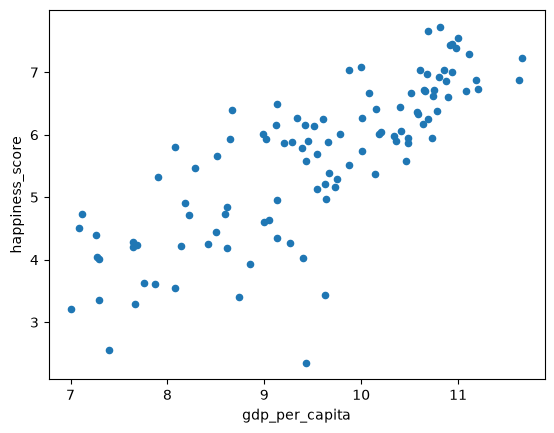

In [72]:
new_df.plot(kind='scatter', x='gdp_per_capita' ,y='happiness_score')

This shows Wealthy people are more happy, as we can see the clear realtionship

array([[<Axes: title={'center': 'happiness_score'}>]], dtype=object)

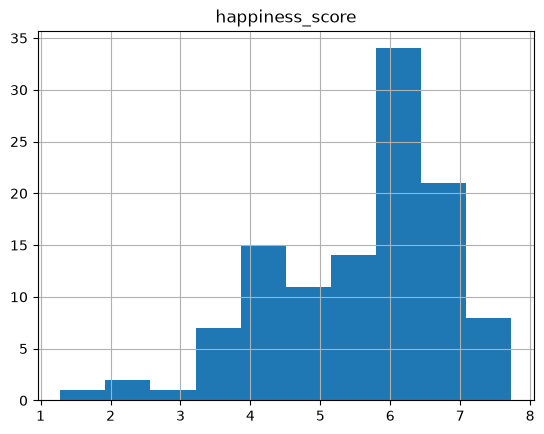

In [73]:
new_df.hist("happiness_score")

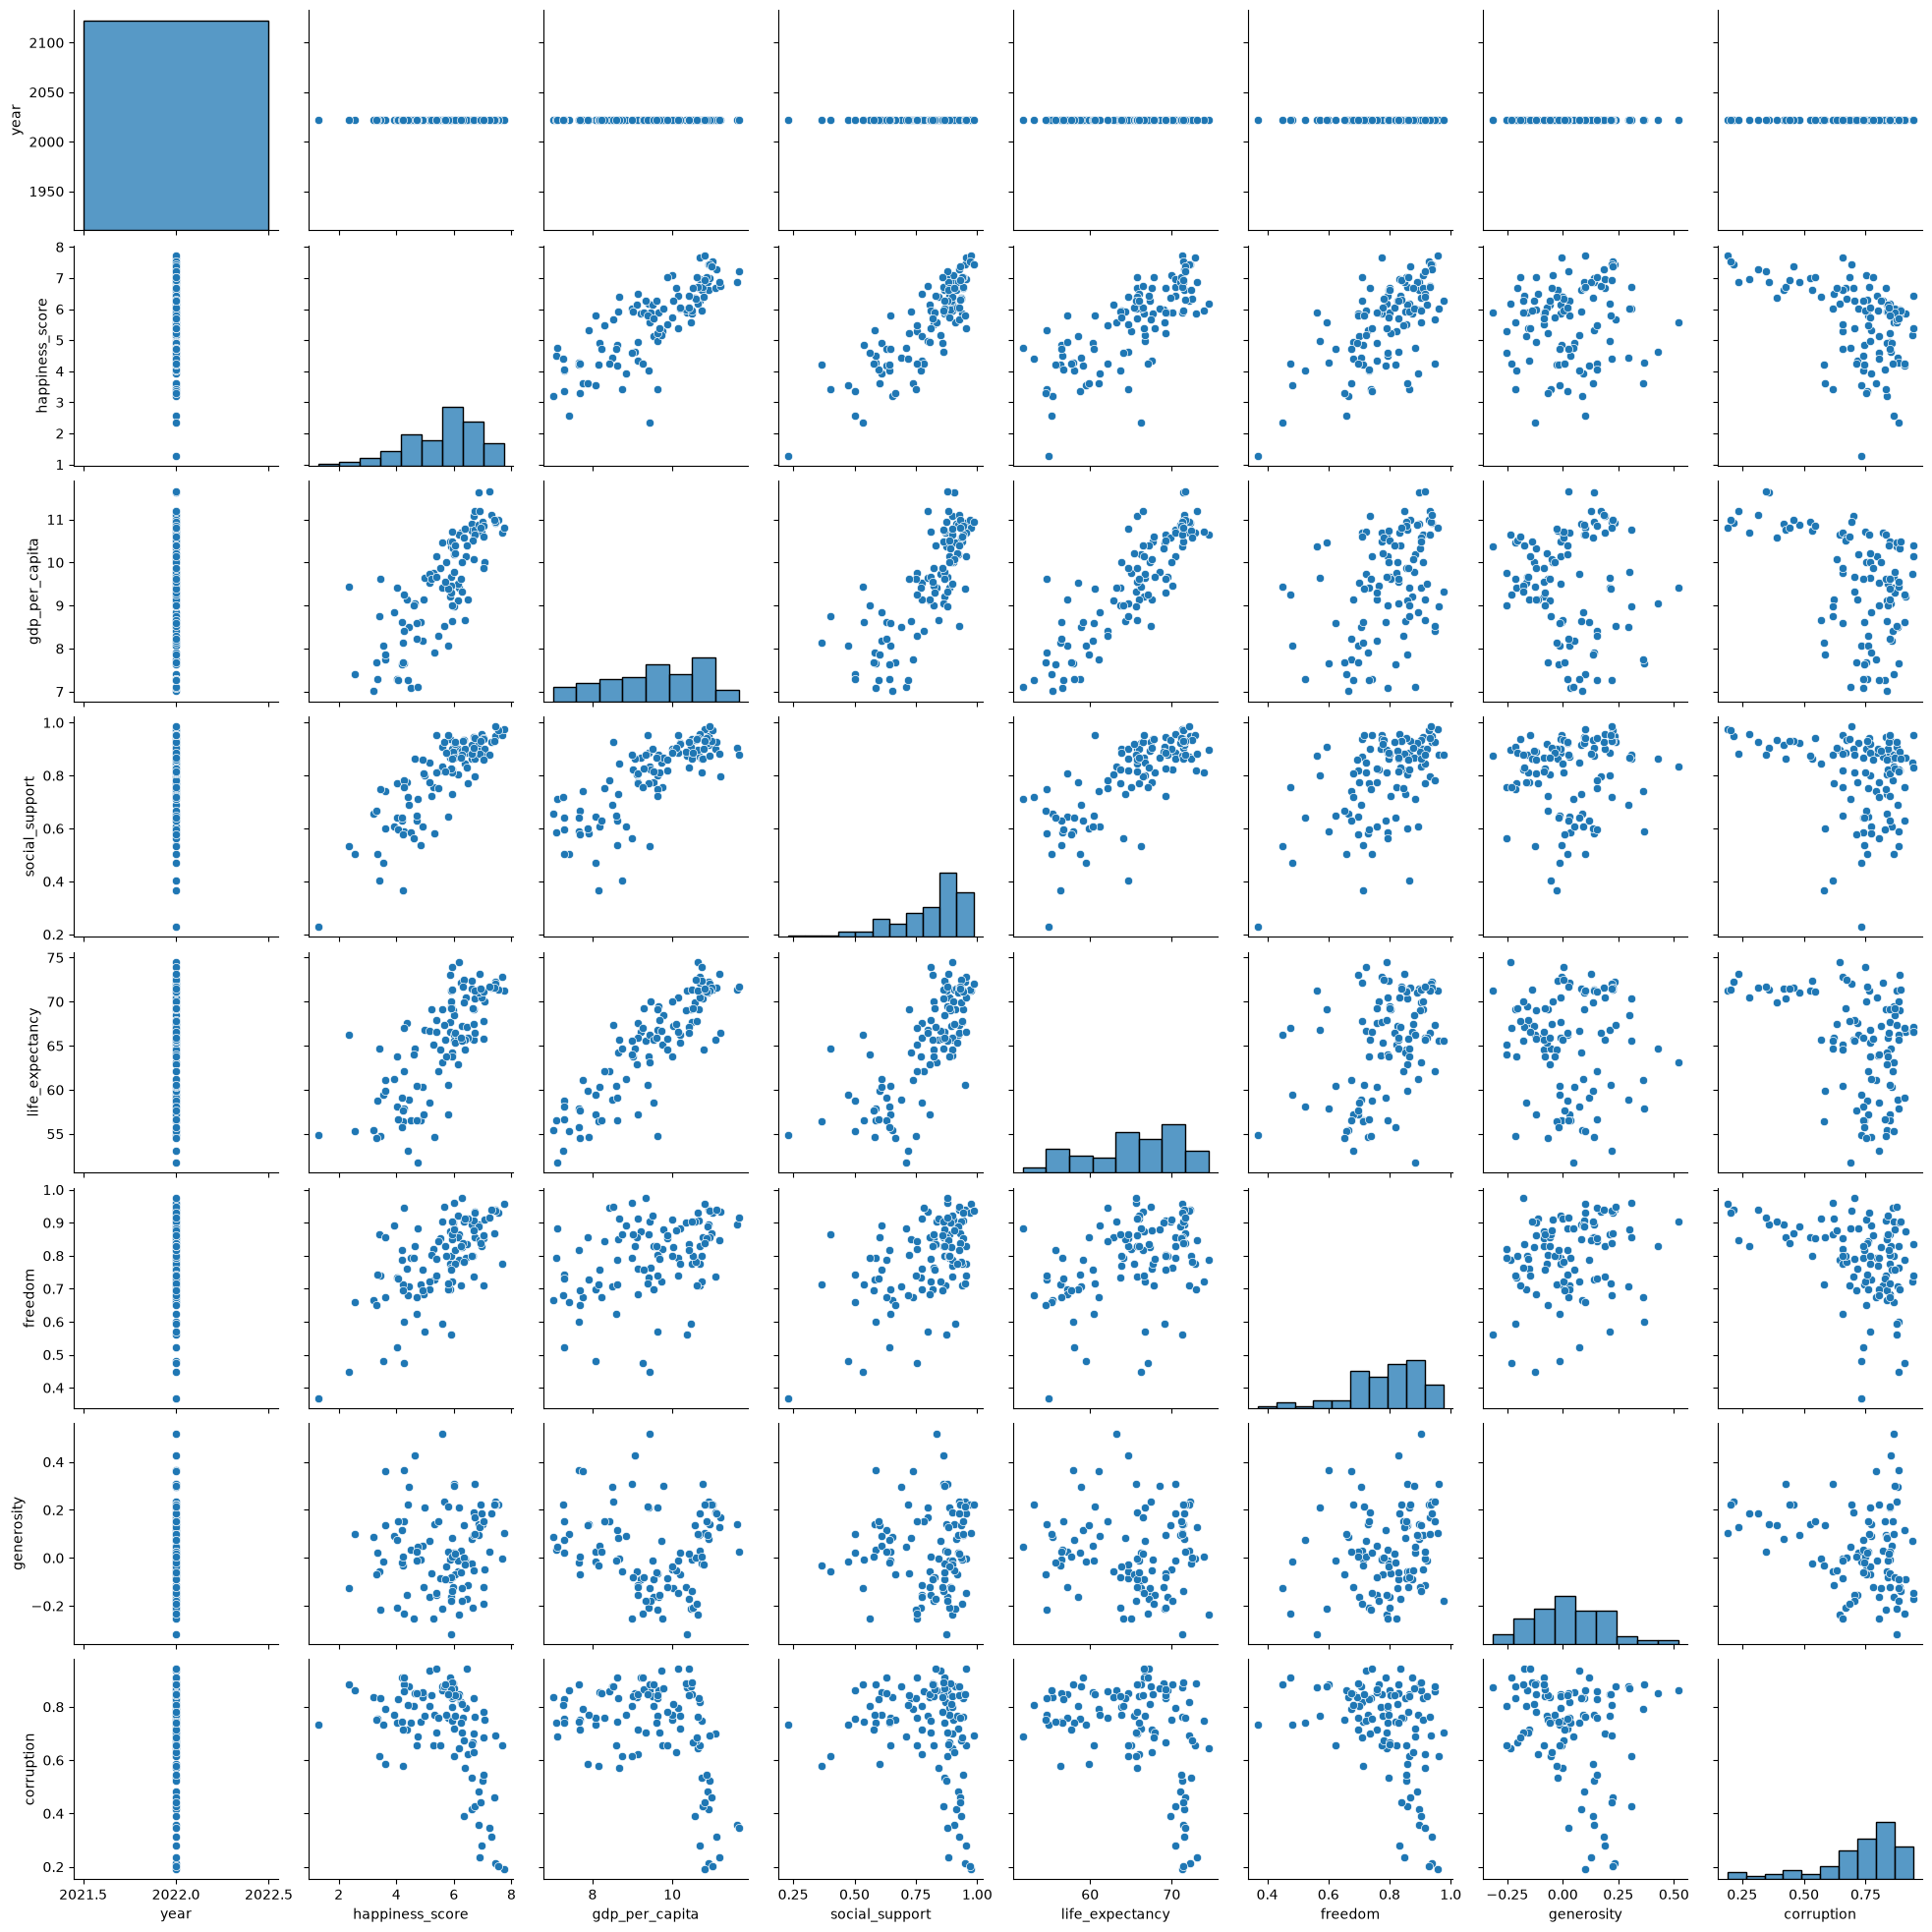

In [75]:
sns.pairplot(data=new_df)